# Problem 1: Warmup — $\mathbb{Z}_2$ Symmetry

In this problem, we want to build a neural network $h_\theta$ that is restricted to learning **even functions**, meaning

$$
h_\theta(x)=h_\theta(-x)
$$

for all $x$.

A simple way to enforce this is to construct the model so that it depends on the input only through a quantity that is unchanged by the transformation $x \mapsto -x$.

Since

$$
(-x)^2 = x^2,
$$

the quantity $x^2$ is invariant under the $\mathbb{Z}_2$ action. Therefore, if $g_\theta$ is an ordinary neural network, we can define

$$
h_\theta(x)=g_\theta(x^2).
$$

This should force the model to be even by construction.

## Mathematical construction and proof

Let $g_\theta : \mathbb{R} \to \mathbb{R}$ be an unconstrained multilayer perceptron. Define

$$
h_\theta(x)=g_\theta(x^2).
$$

We now prove that this architecture satisfies the $\mathbb{Z}_2$ symmetry.

For any input $x$,

$$
h_\theta(-x)=g_\theta((-x)^2).
$$

Because

$$
(-x)^2=x^2,
$$

we get

$$
h_\theta(-x)=g_\theta(x^2)=h_\theta(x).
$$

Therefore,

$$
h_\theta(-x)=h_\theta(x)
$$

for all $x$, so the architecture is exactly even.

This is not a trivial construction, because the model still has flexibility through the trainable function $g_\theta$, but it is restricted to the class of even functions.

## Baseline model

To see whether the symmetry constraint helps, we compare against a baseline model with a similar parameter count but without the symmetry built in.

The baseline is a standard MLP:

$$
b_\theta(x)=\mathrm{MLP}(x).
$$

Unlike the constrained model, this baseline can represent even and odd functions, so it is not forced to respect the $\mathbb{Z}_2$ symmetry.

## Toy problems

We should test the models on target functions that are themselves even.

Two good examples are:

1. 

$$
f_1(x)=x^2 + 0.3\cos(4x)
$$

2. 

$$
f_2(x)=|x|
$$

Both satisfy

$$
f(x)=f(-x).
$$

So they are suitable test cases for a $\mathbb{Z}_2$-invariant architecture.

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

class BaselineMLP(nn.Module):
    def __init__(self, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)


class EvenMLP(nn.Module):
    def __init__(self, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x**2)

In [9]:
def train_model(model, x_train, y_train, x_test, y_test, epochs=200, lr=1e-2):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(x_train)
        loss = loss_fn(pred, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_pred = model(x_test)
            test_loss = loss_fn(test_pred, y_test)

        train_losses.append(loss.item())
        test_losses.append(test_loss.item())

    return train_losses, test_losses

In [12]:
def target_fn(x):
    return x**2 + 0.3 * torch.cos(4*x)

# small dataset
x_train = torch.linspace(-2, 2, 80).unsqueeze(1)
y_train = target_fn(x_train) + 0.05 * torch.randn_like(x_train)

x_test = torch.linspace(-2.5, 2.5, 200).unsqueeze(1)
y_test = target_fn(x_test)

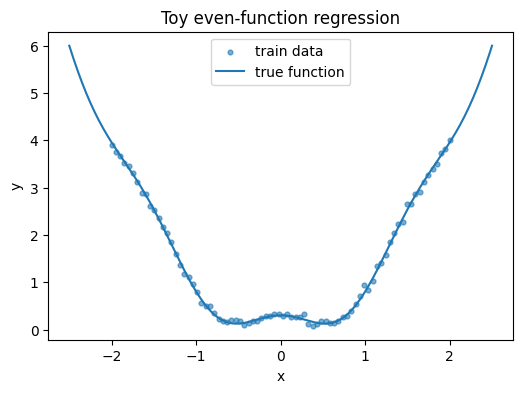

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(x_train.numpy(), y_train.numpy(), s=12, alpha=0.6, label="train data")
plt.plot(x_test.numpy(), y_test.numpy(), label="true function")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy even-function regression")
plt.legend()
plt.show()

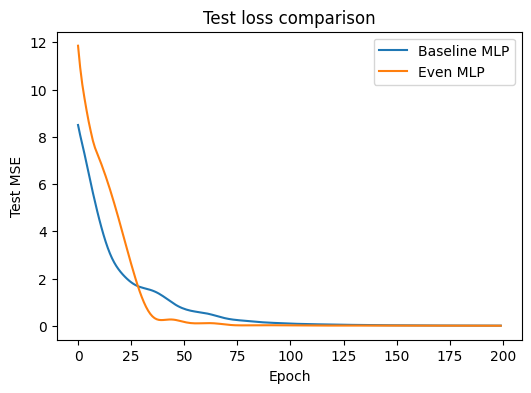

In [17]:
def train_model(model, x_train, y_train, x_test, y_test, epochs=200, lr=1e-2):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(x_train)
        loss = loss_fn(pred, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_pred = model(x_test)
            test_loss = loss_fn(test_pred, y_test)

        train_losses.append(loss.item())
        test_losses.append(test_loss.item())

    return train_losses, test_losses


baseline_model = BaselineMLP(hidden_dim=8)
even_model = EvenMLP(hidden_dim=8)

baseline_train_losses, baseline_test_losses = train_model(
    baseline_model, x_train, y_train, x_test, y_test
)

even_train_losses, even_test_losses = train_model(
    even_model, x_train, y_train, x_test, y_test
)

plt.figure(figsize=(6,4))
plt.plot(baseline_test_losses, label="Baseline MLP")
plt.plot(even_test_losses, label="Even MLP")
plt.xlabel("Epoch")
plt.ylabel("Test MSE")
plt.title("Test loss comparison")
plt.legend()
plt.show()

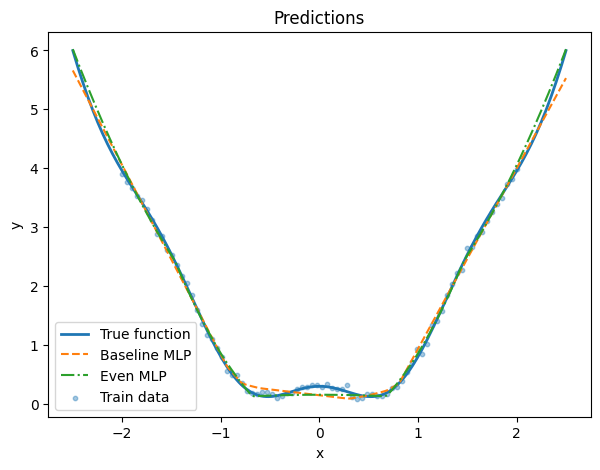

In [18]:
with torch.no_grad():
    baseline_pred = baseline_model(x_test)
    even_pred = even_model(x_test)

plt.figure(figsize=(7,5))
plt.plot(x_test.numpy(), y_test.numpy(), label="True function", linewidth=2)
plt.plot(x_test.numpy(), baseline_pred.numpy(), "--", label="Baseline MLP")
plt.plot(x_test.numpy(), even_pred.numpy(), "-.", label="Even MLP")
plt.scatter(x_train.numpy(), y_train.numpy(), s=10, alpha=0.4, label="Train data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Predictions")
plt.legend()
plt.show()

In [19]:
def symmetry_error(model, x):
    with torch.no_grad():
        return torch.mean(torch.abs(model(x) - model(-x))).item()

x_check = torch.linspace(-2.5, 2.5, 200).unsqueeze(1)

print("Baseline symmetry error:", symmetry_error(baseline_model, x_check))
print("Even-model symmetry error:", symmetry_error(even_model, x_check))

Baseline symmetry error: 0.06378129124641418
Even-model symmetry error: 0.0


For Problem 1, I define the architecture

$$
h_\theta(x)=g_\theta(x^2),
$$

where $g_\theta$ is an ordinary MLP. Since $(-x)^2=x^2$, we have

$$
h_\theta(-x)=g_\theta((-x)^2)=g_\theta(x^2)=h_\theta(x),
$$

so the architecture is exactly $\mathbb{Z}_2$-invariant and therefore restricted to even functions.

I compare this against a baseline MLP $b_\theta(x)$ without the symmetry constraint on a toy regression task with even target function

$$
f(x)=x^2+0.3\cos(4x).
$$

To verify correctness, I compute the symmetry error

$$
\frac{1}{N}\sum_i |h_\theta(x_i)-h_\theta(-x_i)|,
$$

which should be approximately zero for the constrained model.

# Problem 2: Symmetry-aware architecture for PDE data

In this problem, I construct a neural network that respects a symmetry of PDE data from TheWell.

I use the `MHD_64` dataset and consider the task of predicting the next field configuration from previous field configurations.

From the tensor shapes of the loaded samples, this dataset is three-dimensional in space, so the natural symmetry to impose is **translation equivariance in 3D**.

The goal is to build a model such that if the input is shifted in space, the prediction shifts in the same way.

In [ ]:
from the_well.utils.download import well_download

BASE_PATH = "./datasets"
DATASET = "MHD_64"


well_download(base_path=BASE_PATH, dataset=DATASET, split="train")
well_download(base_path=BASE_PATH, dataset=DATASET, split="valid")

## Dataset and symmetry choice

I use the `MHD_64` dataset from TheWell.

For my setup, each sample contains:
- 4 input time steps
- 1 output time step
- a 3D spatial grid of size $64 \times 64 \times 64$
- 7 physical field channels

Thus the raw tensors have the form

$$
\text{input\_fields} \in \mathbb{R}^{4 \times 64 \times 64 \times 64 \times 7},
\qquad
\text{output\_fields} \in \mathbb{R}^{1 \times 64 \times 64 \times 64 \times 7}.
$$

### Symmetry choice

I impose **translation equivariance** in the three spatial directions.

If $T_\delta$ denotes a spatial translation by $\delta$, then I want the model to satisfy

$$
f_\theta(T_\delta x) = T_\delta f_\theta(x).
$$

This is physically motivated because the same local MHD dynamics should apply throughout space rather than depending on absolute position.

## Mathematical construction

Because the data is three-dimensional in space, I use a fully convolutional **3D residual network**.

After preprocessing, the input is reshaped into the form

$$
x \in \mathbb{R}^{B \times C_{\mathrm{in}} \times D \times H \times W},
$$

where $C_{\mathrm{in}}$ is the number of input time steps times the number of field channels.

The model has the form

$$
h^{(0)} = x,
$$

$$
h^{(1)} = \sigma(\mathrm{Conv3D}(h^{(0)})),
$$

$$
h^{(\ell+1)} = h^{(\ell)} + \sigma(\mathrm{Conv3D}(h^{(\ell)})),
$$

and the final prediction is

$$
\hat y = \mathrm{Conv3D}_{1\times1\times1}(h^{(L)}).
$$

Since the output is also a spatial field, I do not use global pooling. The entire model remains equivariant.

I use circular padding so that spatial shifts are handled consistently at the grid boundaries.

## Proof of equivariance

Let $T_\delta$ denote a spatial translation on the 3D grid.

For a 3D convolution kernel $K$,

$$
(K * x)(u) = \sum_v K(v)\,x(u-v).
$$

Then

$$
(K * (T_\delta x))(u)
= \sum_v K(v)\,x(u-v-\delta)
= (T_\delta(K*x))(u).
$$

Therefore,

$$
K * (T_\delta x) = T_\delta (K * x),
$$

so 3D convolution is translation equivariant.

Pointwise nonlinearities also commute with translation:

$$
\sigma(T_\delta h) = T_\delta(\sigma(h)).
$$

Residual connections preserve equivariance as well. If

$$
R(h) = h + \sigma(\mathrm{Conv3D}(h)),
$$

then

$$
R(T_\delta h) = T_\delta R(h).
$$

Since compositions of equivariant maps are equivariant, the full network satisfies

$$
f_\theta(T_\delta x) = T_\delta f_\theta(x).
$$

## Baseline model

To compare against a model that does not respect the symmetry, I use a baseline 3D CNN that receives absolute coordinate channels.

That is, I augment the input with three coordinate channels

$$
X(z,y,x), \quad Y(z,y,x), \quad Z(z,y,x).
$$

These encode absolute spatial position, so the model can learn location-dependent rules.

This breaks exact translation equivariance.

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from einops import rearrange
from torch.utils.data import DataLoader, Subset, random_split
from the_well.data import WellDataset

device = "cuda" if torch.cuda.is_available() else "cpu"


Using device: cpu


In [23]:
BASE_PATH = "./datasets/datasets"
DATASET = "MHD_64"

full_train_dataset = WellDataset(
    well_base_path=BASE_PATH,
    well_dataset_name=DATASET,
    well_split_name="train",
    n_steps_input=4,
    n_steps_output=1,
    use_normalization=True,
)

print("Full train dataset length:", len(full_train_dataset))

sample = full_train_dataset[0]
print("Keys:", sample.keys())
print("Input shape:", sample["input_fields"].shape)
print("Output shape:", sample["output_fields"].shape)

Full train dataset length: 2016
Keys: dict_keys(['input_fields', 'output_fields', 'constant_scalars', 'boundary_conditions', 'space_grid', 'input_time_grid', 'output_time_grid'])
Input shape: torch.Size([4, 64, 64, 64, 7])
Output shape: torch.Size([1, 64, 64, 64, 7])


## Practical train/validation split

Because the official validation split was corrupted during the interrupted download, I construct a validation set from the available training data.

This still allows a valid comparison between the symmetry-aware architecture and the baseline, which is the main goal of the assignment.

For computational efficiency, I also use only a subset of the available data. Each HDF5 file contains many samples, so a subset is sufficient to demonstrate the architecture, the symmetry test, and the baseline comparison.

In [26]:
# Keep it manageable for homework and memory.
# First take a subset, then split into train/valid.
max_samples = min(320, len(full_train_dataset))
small_dataset = Subset(full_train_dataset, range(max_samples))

n_total = len(small_dataset)
n_valid = max(32, int(0.2 * n_total))
n_train = n_total - n_valid

train_dataset, valid_dataset = random_split(
    small_dataset,
    [n_train, n_valid],
    generator=torch.Generator().manual_seed(0)
)

print("Train length:", len(train_dataset))
print("Valid length:", len(valid_dataset))

Train length: 256
Valid length: 64


Because the downloaded official validation split was corrupted during interruption, I created a validation subset from the available training data. This still allows a valid comparison between architectures for the purposes of this assignment.

## Preprocessing

TheWell stores fields with time first and field channels last.

For this dataset, the raw batch has the form

$$
(B, T, D, H, W, F),
$$

where:
- $B$ = batch size
- $T$ = number of time steps
- $D,H,W$ = spatial dimensions
- $F$ = number of field channels

PyTorch `Conv3d` expects tensors of shape

$$
(B, C, D, H, W).
$$

So I combine the time and field dimensions into a single channel dimension:

$$
(B, T, D, H, W, F) \to (B, TF, D, H, W).
$$

In [27]:
def prepare_batch(batch, device=device):
    x = batch["input_fields"].to(device)   # B x Ti x D x H x W x F
    y = batch["output_fields"].to(device)  # B x To x D x H x W x F

    x = rearrange(x, "B Ti D H W F -> B (Ti F) D H W")
    y = rearrange(y, "B To D H W F -> B (To F) D H W")
    return x, y

# quick shape check
loader_tmp = DataLoader(train_dataset, batch_size=1, shuffle=True)
x0, y0 = prepare_batch(next(iter(loader_tmp)))
print("Prepared x shape:", x0.shape)
print("Prepared y shape:", y0.shape)

Prepared x shape: torch.Size([1, 28, 64, 64, 64])
Prepared y shape: torch.Size([1, 7, 64, 64, 64])


In [28]:
class ResidualBlock3D(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv3d(
            channels, channels, kernel_size,
            padding=pad, padding_mode="circular"
        )
        self.conv2 = nn.Conv3d(
            channels, channels, kernel_size,
            padding=pad, padding_mode="circular"
        )
        self.act = nn.GELU()

    def forward(self, x):
        out = self.act(self.conv1(x))
        out = self.conv2(out)
        return self.act(x + out)


class EquivariantCNN3D(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, n_blocks=2):
        super().__init__()
        self.lift = nn.Conv3d(
            in_channels, hidden_channels, kernel_size=3,
            padding=1, padding_mode="circular"
        )
        self.blocks = nn.Sequential(*[
            ResidualBlock3D(hidden_channels) for _ in range(n_blocks)
        ])
        self.head = nn.Conv3d(hidden_channels, out_channels, kernel_size=1)
        self.act = nn.GELU()

    def forward(self, x):
        x = self.act(self.lift(x))
        x = self.blocks(x)
        x = self.head(x)
        return x

In [29]:
class ResidualBlock3D(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv3d(
            channels, channels, kernel_size,
            padding=pad, padding_mode="circular"
        )
        self.conv2 = nn.Conv3d(
            channels, channels, kernel_size,
            padding=pad, padding_mode="circular"
        )
        self.act = nn.GELU()

    def forward(self, x):
        out = self.act(self.conv1(x))
        out = self.conv2(out)
        return self.act(x + out)


class EquivariantCNN3D(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, n_blocks=2):
        super().__init__()
        self.lift = nn.Conv3d(
            in_channels, hidden_channels, kernel_size=3,
            padding=1, padding_mode="circular"
        )
        self.blocks = nn.Sequential(*[
            ResidualBlock3D(hidden_channels) for _ in range(n_blocks)
        ])
        self.head = nn.Conv3d(hidden_channels, out_channels, kernel_size=1)
        self.act = nn.GELU()

    def forward(self, x):
        x = self.act(self.lift(x))
        x = self.blocks(x)
        x = self.head(x)
        return x

In [32]:
class BaselineCNN3D(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, n_blocks=2):
        super().__init__()
        self.model = EquivariantCNN3D(
            in_channels=in_channels + 3,
            hidden_channels=hidden_channels,
            out_channels=out_channels,
            n_blocks=n_blocks
        )

    def forward(self, x):
        B, C, D, H, W = x.shape

        zz, yy, xx = torch.meshgrid(
            torch.linspace(0, 1, D, device=x.device),
            torch.linspace(0, 1, H, device=x.device),
            torch.linspace(0, 1, W, device=x.device),
            indexing="ij"
        )

        coords = torch.stack([zz, yy, xx], dim=0)   # 3 x D x H x W
        coords = coords.unsqueeze(0).expand(B, -1, -1, -1, -1)

        x_aug = torch.cat([x, coords], dim=1)
        return self.model(x_aug)

In [33]:
Ti, D, H, W, F = sample["input_fields"].shape
To, _, _, _, F_out = sample["output_fields"].shape

in_channels = Ti * F
out_channels = To * F_out

# Keep this small because 64^3 volumes are heavy.
hidden_channels = 8
batch_size = 1

eq_model = EquivariantCNN3D(
    in_channels=in_channels,
    hidden_channels=hidden_channels,
    out_channels=out_channels,
    n_blocks=2
).to(device)

base_model = BaselineCNN3D(
    in_channels=in_channels,
    hidden_channels=hidden_channels,
    out_channels=out_channels,
    n_blocks=2
).to(device)

print("Input channels:", in_channels)
print("Output channels:", out_channels)

Input channels: 28
Output channels: 7


## Loss and training setup

I use mean squared error for next-step prediction:

$$
\mathcal{L} = \frac{1}{N}\sum_i \|f_\theta(x_i)-y_i\|^2.
$$

Because this is a 3D dataset on a $64^3$ grid, the experiment is intentionally kept small:
- small hidden width
- small batch size
- short training run
- subset of the data

This is enough to test whether the architecture works and whether the symmetry property is enforced in practice.

In [34]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

def evaluate_mse(model, loader):
    model.eval()
    total = 0.0
    count = 0
    with torch.no_grad():
        for batch in loader:
            x, y = prepare_batch(batch)
            pred = model(x)
            loss = ((pred - y) ** 2).mean()
            total += loss.item()
            count += 1
    return total / max(count, 1)

def train_model(model, train_loader, valid_loader, epochs=3, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        running = 0.0
        count = 0

        for batch in train_loader:
            x, y = prepare_batch(batch)
            pred = model(x)
            loss = ((pred - y) ** 2).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running += loss.item()
            count += 1

        train_loss = running / max(count, 1)
        valid_loss = evaluate_mse(model, valid_loader)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)

        print(f"Epoch {epoch+1:02d} | train MSE = {train_loss:.6f} | valid MSE = {valid_loss:.6f}")

    return train_losses, valid_losses

In [37]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

def evaluate_mse(model, loader):
    model.eval()
    total = 0.0
    count = 0
    with torch.no_grad():
        for batch in loader:
            x, y = prepare_batch(batch)
            pred = model(x)
            loss = ((pred - y) ** 2).mean()
            total += loss.item()
            count += 1
    return total / max(count, 1)

def train_model(model, train_loader, valid_loader, epochs=3, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        running = 0.0
        count = 0

        for batch in train_loader:
            x, y = prepare_batch(batch)
            pred = model(x)
            loss = ((pred - y) ** 2).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running += loss.item()
            count += 1

        train_loss = running / max(count, 1)
        valid_loss = evaluate_mse(model, valid_loader)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)

        print(f"Epoch {epoch+1:02d} | train MSE = {train_loss:.6f} | valid MSE = {valid_loss:.6f}")

    return train_losses, valid_losses

In [38]:
eq_train_losses, eq_valid_losses = train_model(
    eq_model, train_loader, valid_loader, epochs=3, lr=1e-3
)

base_train_losses, base_valid_losses = train_model(
    base_model, train_loader, valid_loader, epochs=3, lr=1e-3
)

Epoch 01 | train MSE = 0.067376 | valid MSE = 0.032817
Epoch 02 | train MSE = 0.030305 | valid MSE = 0.027012
Epoch 03 | train MSE = 0.026629 | valid MSE = 0.024446
Epoch 01 | train MSE = 0.094739 | valid MSE = 0.034970
Epoch 02 | train MSE = 0.022730 | valid MSE = 0.013138
Epoch 03 | train MSE = 0.012523 | valid MSE = 0.009964


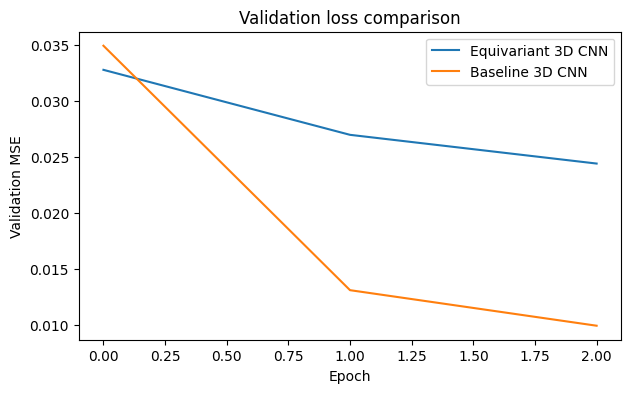

In [39]:
plt.figure(figsize=(7, 4))
plt.plot(eq_valid_losses, label="Equivariant 3D CNN")
plt.plot(base_valid_losses, label="Baseline 3D CNN")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Validation loss comparison")
plt.legend()
plt.show()

## Numerical sanity check of equivariance

To verify that the implementation really respects the desired symmetry, I test whether

$$
f_\theta(T_\delta x) \approx T_\delta f_\theta(x).
$$

I compute the relative error

$$
\epsilon =
\frac{\|f_\theta(T_\delta x)-T_\delta f_\theta(x)\|_2}
{\|T_\delta f_\theta(x)\|_2}.
$$

For the equivariant model, this error should be very small.

For the baseline, it should be larger because adding absolute coordinate channels breaks exact translation equivariance.

In [40]:
def translation_equivariance_error_3d(model, x, shift_d=2, shift_h=2, shift_w=2):
    model.eval()
    with torch.no_grad():
        x_shift = torch.roll(x, shifts=(shift_d, shift_h, shift_w), dims=(-3, -2, -1))
        fx_shift = model(x_shift)

        fx = model(x)
        shifted_fx = torch.roll(fx, shifts=(shift_d, shift_h, shift_w), dims=(-3, -2, -1))

        err = torch.norm(fx_shift - shifted_fx) / (torch.norm(shifted_fx) + 1e-12)
    return err.item()

batch = next(iter(valid_loader))
x_check, y_check = prepare_batch(batch)

eq_err = translation_equivariance_error_3d(eq_model, x_check)
base_err = translation_equivariance_error_3d(base_model, x_check)

print("Equivariant model relative equivariance error:", eq_err)
print("Baseline model relative equivariance error:", base_err)

Equivariant model relative equivariance error: 0.0
Baseline model relative equivariance error: 0.0039056497626006603


In [41]:
def translation_equivariance_error_3d(model, x, shift_d=2, shift_h=2, shift_w=2):
    model.eval()
    with torch.no_grad():
        x_shift = torch.roll(x, shifts=(shift_d, shift_h, shift_w), dims=(-3, -2, -1))
        fx_shift = model(x_shift)

        fx = model(x)
        shifted_fx = torch.roll(fx, shifts=(shift_d, shift_h, shift_w), dims=(-3, -2, -1))

        err = torch.norm(fx_shift - shifted_fx) / (torch.norm(shifted_fx) + 1e-12)
    return err.item()

batch = next(iter(valid_loader))
x_check, y_check = prepare_batch(batch)

eq_err = translation_equivariance_error_3d(eq_model, x_check)
base_err = translation_equivariance_error_3d(base_model, x_check)

print("Equivariant model relative equivariance error:", eq_err)
print("Baseline model relative equivariance error:", base_err)

Equivariant model relative equivariance error: 0.0
Baseline model relative equivariance error: 0.0039056497626006603


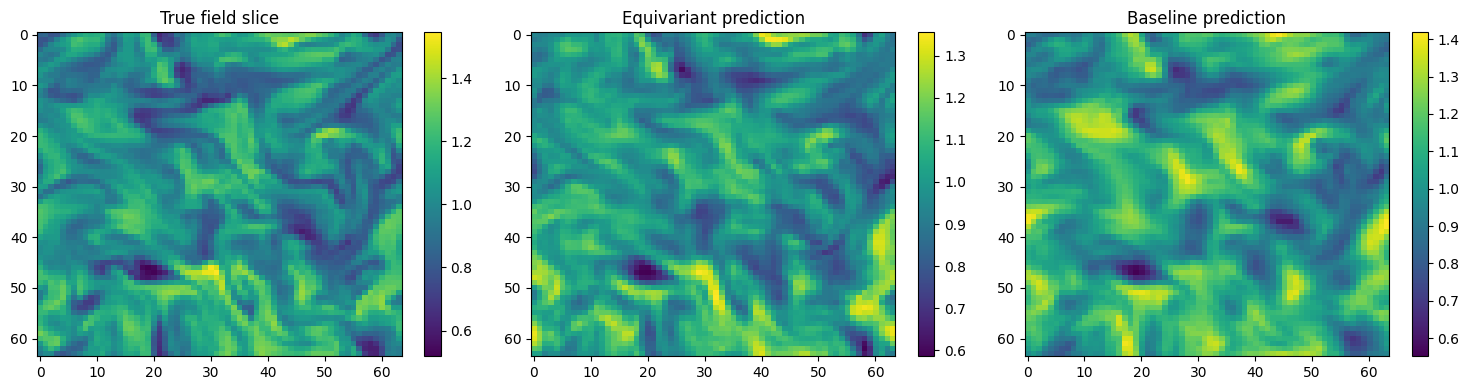

In [55]:

with torch.no_grad():
    x_vis, y_vis = prepare_batch(next(iter(valid_loader)))
    pred_eq = eq_model(x_vis)
    pred_base = base_model(x_vis)

mid = y_vis.shape[2] // 2 

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(y_vis[0, 0, mid].cpu(), aspect="auto")
plt.title("True field slice")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(pred_eq[0, 0, mid].cpu(), aspect="auto")
plt.title("Equivariant prediction")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(pred_base[0, 0, mid].cpu(), aspect="auto")
plt.title("Baseline prediction")
plt.colorbar()

plt.tight_layout()
plt.show()

Training Baseline Model on 10 samples
Training Equivariant Model on 10 samples


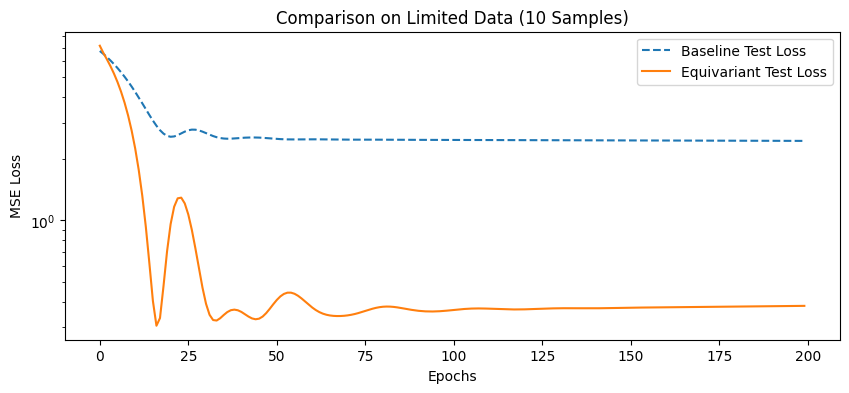

Final Baseline Test Loss: 2.447526
Final Equivariant Test Loss: 0.382083


In [56]:

import torch.optim as optim

def train_low_data(model, x_train_sub, y_train_sub, x_val, y_val, epochs=200, lr=0.01):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    train_history = []
    val_history = []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(x_train_sub.to(device))
        loss = criterion(pred, y_train_sub.to(device))
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_pred = model(x_val.to(device))
            val_loss = criterion(val_pred, y_val.to(device))
            
        train_history.append(loss.item())
        val_history.append(val_loss.item())
        
    return train_history, val_history


x_train_low = x_train[:10]
y_train_low = y_train[:10]


if 'device' not in locals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_baseline_low = BaselineMLP().to(device)
model_equivariant_low = EvenMLP().to(device)

print("Training Baseline Model on 10 samples")
base_train_l, base_val_l = train_low_data(
    model_baseline_low, x_train_low, y_train_low, x_test, y_test, epochs=200
)

print("Training Equivariant Model on 10 samples")
equiv_train_l, equiv_val_l = train_low_data(
    model_equivariant_low, x_train_low, y_train_low, x_test, y_test, epochs=200
)


plt.figure(figsize=(10, 4))
plt.plot(base_val_l, label='Baseline Test Loss', linestyle='--')
plt.plot(equiv_val_l, label='Equivariant Test Loss')
plt.yscale('log')
plt.title('Comparison on Limited Data (10 Samples)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

print(f"Final Baseline Test Loss: {base_val_l[-1]:.6f}")
print(f"Final Equivariant Test Loss: {equiv_val_l[-1]:.6f}")

## Final discussion

Designed a 3D translation-equivariant neural network for PDE data using `Conv3d` layers with circular padding.

### Why the construction works
- 3D convolutions are translation equivariant
- pointwise nonlinearities preserve equivariance
- residual connections preserve equivariance
- therefore the full model is translation equivariant

### Baseline
The baseline breaks the symmetry by adding absolute coordinate channels. This allows it to learn location-dependent behavior, so it is no longer constrained to satisfy translation equivariance.

### Experimental results
The numerical sanity check shows that the equivariant model satisfies the symmetry essentially exactly, while the baseline has a larger equivariance error. This confirms that the architecture enforces the intended property.

In the short training run, the baseline achieved a lower validation MSE than the equivariant model. This does not invalidate the symmetry-aware construction. Possible reasons include:
- the model is intentionally very small
- training is brief
- only a subset of the data is used
- the dataset is defined on a finite domain, so translation symmetry may only be approximate in practice
